# 🧠 Evaluación y selección del modelo de embeddings

## 🌍 Contexto

Para que un sistema de búsqueda inteligente pueda encontrar artículos relevantes ante una pregunta del usuario, necesita representar tanto los artículos como las preguntas en un **espacio matemático común** — una forma de convertir texto en números que capture su significado.

Esta conversión la realiza un **modelo de embeddings**: un algoritmo de inteligencia artificial que transforma cualquier texto en un vector de números (por ejemplo, una lista de 768 o 1024 valores). Textos con significados similares quedan cerca en ese espacio matemático; textos distintos quedan lejos.

El problema es que existen muchos modelos de embeddings, y no todos funcionan igual de bien para textos médicos y científicos. Algunos son modelos generalistas (entrenados con texto de internet en general) y otros son modelos especializados en el dominio biomédico (entrenados con literatura médica).

---

## 🎯 Objetivo

Comparar varios modelos de embeddings para determinar cuál ofrece el **mejor equilibrio entre calidad de recuperación y coste computacional** para nuestro caso de uso: recuperación semántica de artículos científicos biomédicos.

---

## ⚙️ Estrategia

Evaluamos los modelos desde dos perspectivas:

- **Calidad del retrieval** — ¿qué artículos devuelve cada modelo ante las mismas preguntas? ¿Son relevantes?
- **Coste computacional** — ¿cuánto tiempo tarda en procesar el corpus y en responder a una consulta?

Para la evaluación usamos un corpus de artículos reales sobre microbiota e inflamación, y un conjunto de consultas representativas del caso de uso.

---

## 🧩 Pasos que seguimos

### 1. Carga del corpus y las consultas
Preparamos el conjunto de artículos que usaremos como base de prueba y definimos las preguntas de evaluación.

### 2. Carga de los modelos
Cargamos cada modelo y registramos sus características principales (dimensión del vector, número de parámetros, tipo de especialización).

### 3. Generación de embeddings
Para cada modelo, convertimos todos los artículos y todas las consultas en vectores y medimos el tiempo que tarda.

### 4. Evaluación del retrieval
Para cada consulta y cada modelo, buscamos los artículos más similares y comparamos los resultados: ¿devuelve los mismos artículos? ¿Con qué puntuación? ¿Son relevantes?

### 5. Comparativa y decisión
Construimos una tabla resumen con los resultados de todos los modelos y tomamos una decisión justificada sobre cuál usar en el sistema final.

---

> **💡 Insight clave**
> Un score más alto no significa necesariamente mejor recuperación. Un modelo puede dar puntuaciones muy altas pero recuperar artículos poco relevantes. Lo que buscamos es **consistencia y coherencia** en los resultados, no el score más elevado.

> **🚀 Qué NO hacemos aquí**
> Este notebook evalúa los modelos de forma aislada. La integración del modelo seleccionado en el pipeline completo (extracción → embedding → indexación → búsqueda) se realiza en los notebooks de ingesta e indexación.

In [1]:
# Importamos librerias y cargamos API key

from extraction_and_parse import *

import os
from dotenv import load_dotenv
import requests
from xml.etree import ElementTree as ET

import time
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer, util
from google import genai
from IPython.display import display

/Users/gloriadelriomarquez/Documents/Career/Master Pontia/10. BD vectoriales/Entrega/project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


API Key cargada.


In [2]:
load_dotenv()
ncbi_api_key = os.getenv('NCBI_API_KEY')
google_api_key = os.getenv('GOOGLE_API_KEY')

print("API Key cargada." if (ncbi_api_key and google_api_key) else "API Key no encontrada")

API Key cargada.


In [3]:
client = genai.Client(api_key=google_api_key)

for model in client.models.list():
    if "embed" in model.name.lower():
        print(model.name)

result = client.models.embed_content(
    model="gemini-embedding-2-preview",
    contents="hello world"
)
print(f"\nAPI key OK — dimensión: {len(result.embeddings[0].values)}")

models/gemini-embedding-001
models/gemini-embedding-2-preview

API key OK — dimensión: 3072


# Evaluación modelos embeddings 
Realizamos una prueba para comparar, para un conjunto de querys, qué artículos pone cada modelo en el top 3 y con qué score. Esto nos servirá como demo/comparativa de modelos de embeddings. 

Sin embargo, sabemos que un score más alto no implica automáticamente mejor recuperación. Puede ocurrir que un modelo dé scores altos pero con documentos peores. 

•	corpus → en nuestro caso se generará con los embedding_text de los artículos 
•	queries → preguntas o consultas cortas relacionadas con microbiota e inflamación
•	modelos → 3 modelos de embeddings
•	evaluación simple → mirar top-k recuperados y comparar score de resultados

In [4]:
# -------------- GEMINI API WRAPPER --------------

class GeminiEmbeddingWrapper:
    def __init__(self, model_name="gemini-embedding-2-preview"):
        self.model_name = model_name

    def encode(self, texts, convert_to_tensor=False, show_progress_bar=False, task_type="retrieval_document"):
        import torch, time
        if isinstance(texts, str):
            texts = [texts]
        embeddings = []
        for text in texts:
            result = client.models.embed_content(
                model=self.model_name,
                contents=text,
                config={"task_type": task_type}
            )
            embeddings.append(result.embeddings[0].values)
            time.sleep(0.05)
        tensor = torch.tensor(embeddings)
        return tensor

In [5]:
#  -------------- PREPARAR CORPUS Y QUERIES --------------

def build_corpus_from_articles(articles):
    """
    Extrae el texto a embeber y conserva referencia al artículo original.
    """
    corpus_texts = []
    corpus_meta = []

    for art in articles:
        corpus_texts.append(art["embedding_text"])
        corpus_meta.append({
            "document_id": art["document_id"],
            "pmid": art["pmid"],
            "title": art["title"],
            "journal": art["metadata"].get("journal"),
            "best_date": art["metadata"].get("best_date")
        })

    return corpus_texts, corpus_meta


# Consultas de prueba para vuestro caso de uso
queries = [
    "gut microbiota and systemic inflammation",
    "intestinal permeability and low-grade inflammation",
    "dietary modulation of gut microbiota",
    "microbiota in autoimmune thyroid disease",
    "probiotics and inflammatory response"
]


# MODELOS A COMPARAR
# - uno generalista
# - uno biomédico de embeddings
# - uno sentence-transformer biomédico

MODELS = {
    "bge-m3": "BAAI/bge-m3",
    "pubmedbert-embeddings": "NeuML/pubmedbert-base-embeddings",
    "s-pubmedbert-medquad": "TimKond/S-PubMedBert-MedQuAD", 
    "gemini-embedding-2-preview": "gemini-embedding-2-preview" 
}

# Metadatos para la tabla comparativa final.
MODEL_INFO = {
    "bge-m3": {
        "type": "generalist",
        "approx_params_millions": 568,
        "notes": "open-source general-purpose embedding model"
    },
    "pubmedbert-embeddings": {
        "type": "biomedical",
        "approx_params_millions": 110,
        "notes": "PubMedBERT adapted for embeddings"
    },
    "s-pubmedbert-medquad": {
        "type": "biomedical-sentence-similarity",
        "approx_params_millions": 110,
        "notes": "PubMedBERT adapted for sentence similarity / retrieval"
    }, 
    "gemini-embedding-2-preview": {
        "type": "API-based",
        "approx_params_millions": None,
        "notes": "Google gemini-embedding-2-preview via Gemini API"
    }

}

In [6]:
# -------------- HELPERS --------------

def format_queries_for_model(model_name, queries):
    """
    Algunos modelos, como e5, requieren prefijos tipo 'query:'.
    """
    if "e5" in model_name.lower():
        return [f"query: {q}" for q in queries]
    return queries


def format_corpus_for_model(model_name, corpus):
    """
    Algunos modelos, como e5, requieren prefijos tipo 'passage:'.
    """
    if "e5" in model_name.lower():
        return [f"passage: {doc}" for doc in corpus]
    return corpus


def load_models(model_dict, device):
    """
    Carga los modelos compatibles con sentence-transformers.
    Si alguno falla, se omite para no romper toda la comparativa.
    """
    loaded_models = {}
    failed_models = {}

    for alias, official_name in model_dict.items():

        print(f"Cargando modelo: {alias} -> {official_name}")
        if alias.startswith("gemini"):
            loaded_models[alias] = GeminiEmbeddingWrapper(model_name=official_name)
            continue
        try:
            loaded_models[alias] = SentenceTransformer(
                official_name,
                device=device,
                trust_remote_code=True
            )
        except Exception as exc:
            failed_models[alias] = str(exc)
            print(f"No se pudo cargar {alias}: {exc}")
            print("Se omite este modelo y la comparacion continua con los demas.")

    if not loaded_models:
        raise ValueError("No se pudo cargar ningun modelo compatible.")

    if failed_models:
        print("\nModelos omitidos:")
        for alias, error in failed_models.items():
            print(f"- {alias}: {error}")

    return loaded_models


def encode_corpus_and_queries(models, corpus_texts, queries):
    """
    Genera embeddings para corpus y queries con cada modelo y mide tiempos.
    """
    embeddings = {}

    for model_alias, model in models.items():
        print(f"\nGenerando embeddings con: {model_alias}")


        corpus_input = format_corpus_for_model(model_alias, corpus_texts)
        query_input = format_queries_for_model(model_alias, queries)


        with torch.no_grad():
            start_encoding_corpus = time.time()
            corpus_encode_kwargs = {
                "convert_to_tensor": True,
                "show_progress_bar": False
            }
            query_encode_kwargs = {
                "convert_to_tensor": True,
                "show_progress_bar": False
            }

            if model_alias.startswith("gemini"):
                corpus_encode_kwargs["task_type"] = "retrieval_document"
                query_encode_kwargs["task_type"] = "retrieval_query"

            corpus_emb = model.encode(corpus_input, **corpus_encode_kwargs)
            end_encoding_corpus = time.time()

            start_encoding_queries = time.time()
            query_emb = model.encode(query_input, **query_encode_kwargs)
            end_encoding_queries = time.time()

        corpus_time = end_encoding_corpus - start_encoding_corpus
        query_time = end_encoding_queries - start_encoding_queries

        embeddings[model_alias] = {
            "corpus_embeddings": corpus_emb,
            "query_embeddings": query_emb,
            "dimension": corpus_emb.shape[1],
            "corpus_encoding_time_sec": corpus_time,
            "query_encoding_time_sec": query_time,
            "avg_doc_encoding_time_sec": corpus_time / len(corpus_texts) if corpus_texts else None,
            "avg_query_encoding_time_sec": query_time / len(queries) if queries else None
        }

        print(f"Dimensión embeddings ({model_alias}): {corpus_emb.shape[1]}")
        print(f"Tiempo corpus ({model_alias}): {corpus_time:.4f} s")
        print(f"Tiempo queries ({model_alias}): {query_time:.4f} s")

    return embeddings

def semantic_search_one_query(query_embedding, corpus_embeddings, corpus_meta, top_k=3):
    """
    Realiza búsqueda semántica para una única query.
    """
    hits = util.semantic_search(query_embedding, corpus_embeddings, top_k=top_k)[0]

    results = []
    for rank, hit in enumerate(hits, start=1):
        doc_idx = hit["corpus_id"]
        score = float(hit["score"])

        results.append({
            "rank": rank,
            "score": score,
            "document_id": corpus_meta[doc_idx]["document_id"],
            "pmid": corpus_meta[doc_idx]["pmid"],
            "title": corpus_meta[doc_idx]["title"],
            "journal": corpus_meta[doc_idx]["journal"],
            "best_date": corpus_meta[doc_idx]["best_date"]
        })

    return results


def compare_models_for_queries(models, embeddings, queries, corpus_meta, top_k=3):
    """
    Ejecuta búsqueda semántica para cada query y cada modelo.
    También mide tiempo de búsqueda por query y por modelo.
    """
    detailed_results = []
    summary_results = []

    for q_idx, query_text in enumerate(queries):
        print("\n" + "=" * 100)
        print(f"QUERY: {query_text}")
        print("=" * 100)

        for model_alias in embeddings.keys():
            query_embedding = embeddings[model_alias]["query_embeddings"][q_idx]
            corpus_embeddings = embeddings[model_alias]["corpus_embeddings"]

            search_start = time.time()
            top_hits = semantic_search_one_query(
                query_embedding=query_embedding,
                corpus_embeddings=corpus_embeddings,
                corpus_meta=corpus_meta,
                top_k=top_k
            )
            search_end = time.time()

            search_time = search_end - search_start

            print(f"\n--- Modelo: {model_alias} ---")
            for hit in top_hits:
                print(f"[{hit['rank']}] score={hit['score']:.4f} | PMID={hit['pmid']} | {hit['title']}")

                detailed_results.append({
                    "query": query_text,
                    "model": model_alias,
                    "rank": hit["rank"],
                    "score": hit["score"],
                    "document_id": hit["document_id"],
                    "pmid": hit["pmid"],
                    "title": hit["title"],
                    "journal": hit["journal"],
                    "best_date": hit["best_date"],
                    "search_time_sec": search_time
                })

            summary_results.append({
                "query": query_text,
                "model": model_alias,
                "top_1_score": top_hits[0]["score"],
                "top_1_pmid": top_hits[0]["pmid"],
                "top_1_title": top_hits[0]["title"],
                "search_time_sec": search_time
            })

    df_detailed = pd.DataFrame(detailed_results)
    df_summary = pd.DataFrame(summary_results)

    return df_detailed, df_summary

In [7]:
# TABLAS, GRÁFICOS Y COMPARACIONES 

def build_model_comparison_table(embeddings, df_summary, model_info):
    """
    Construye tabla comparativa final:
    - tipo
    - nº de parámetros aproximado
    - dimensión embedding
    - tiempos
    - score medio top-1
    """
    rows = []

    grouped_scores = (
        df_summary.groupby("model", as_index=False)
        .agg(
            avg_top1_score=("top_1_score", "mean"),
            min_top1_score=("top_1_score", "min"),
            max_top1_score=("top_1_score", "max"),
            avg_search_time_sec=("search_time_sec", "mean")
        )
    )

    score_lookup = grouped_scores.set_index("model").to_dict(orient="index")

    for model_alias, emb_data in embeddings.items():
        info = model_info.get(model_alias, {})

        rows.append({
            "model": model_alias,
            "type": info.get("type"),
            "approx_params_millions": info.get("approx_params_millions"),
            "embedding_dimension": emb_data["dimension"],
            "corpus_encoding_time_sec": round(emb_data["corpus_encoding_time_sec"], 4),
            "query_encoding_time_sec": round(emb_data["query_encoding_time_sec"], 4),
            "avg_doc_encoding_time_sec": round(emb_data["avg_doc_encoding_time_sec"], 6),
            "avg_query_encoding_time_sec": round(emb_data["avg_query_encoding_time_sec"], 6),
            "avg_search_time_sec": round(score_lookup.get(model_alias, {}).get("avg_search_time_sec", float("nan")), 6),
            "avg_top1_score": round(score_lookup.get(model_alias, {}).get("avg_top1_score", float("nan")), 4),
            "min_top1_score": round(score_lookup.get(model_alias, {}).get("min_top1_score", float("nan")), 4),
            "max_top1_score": round(score_lookup.get(model_alias, {}).get("max_top1_score", float("nan")), 4),
            "notes": info.get("notes")
        })

    df_models = pd.DataFrame(rows)
    df_models = df_models.sort_values(by="avg_top1_score", ascending=False).reset_index(drop=True)

    return df_models


def plot_top1_scores(df_summary):
    """
    Gráfico simple con matplotlib: score del primer resultado por query y modelo.
    """
    pivot_df = df_summary.pivot(index="query", columns="model", values="top_1_score")

    ax = pivot_df.plot(kind="bar", figsize=(14, 7))
    ax.set_title("Comparación del score del primer resultado por modelo")
    ax.set_xlabel("Query")
    ax.set_ylabel("Top-1 cosine similarity")
    plt.xticks(rotation=20, ha="right")
    plt.legend(title="Modelo")
    plt.tight_layout()
    plt.show()


def plot_encoding_times(df_models):
    import matplotlib.pyplot as plt
    import numpy as np

    models = df_models["model"]
    corpus_times = df_models["corpus_encoding_time_sec"]
    query_times = df_models["query_encoding_time_sec"]

    x = np.arange(len(models))
    width = 0.4

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Colores
    color_corpus = "tab:blue"
    color_query = "tab:orange"

    # Eje izquierdo → corpus
    bars1 = ax1.bar(x - width/2, corpus_times, width, color=color_corpus, label="Corpus time")
    ax1.set_ylabel("Tiempo corpus (segundos)", color=color_corpus)
    ax1.tick_params(axis='y', labelcolor=color_corpus)

    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=20)

    # Eje derecho → queries
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, query_times, width, color=color_query, label="Query time")
    ax2.set_ylabel("Tiempo queries (segundos)", color=color_query)
    ax2.tick_params(axis='y', labelcolor=color_query)

    # Título
    plt.title("Comparación de tiempos de generación de embeddings")

    # Leyenda combinada
    ax1.legend([bars1, bars2], ["Corpus", "Queries"])

    plt.tight_layout()
    plt.show()


In [8]:
# PIPELINE DE PRUEBA

# device: usa GPU si tienes, si no CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Para una demo, empezamos con 10-20 artículos. 
# Finalmente aumentamos a 50 para ver diferencias más "realistas" entre modelos
pipeline_result = build_pubmed_article_dicts(
    query="gut microbiota AND systemic inflammation",
    n=50
)
print(f"PMIDs recuperados: {len(pipeline_result['pmids'])}")
print(f"Primeros PMIDs: {pipeline_result['pmids'][:5]}")

articles = pipeline_result["articles"]
print(f"Número de artículos: {len(articles)}")

corpus_texts, corpus_meta = build_corpus_from_articles(articles)

loaded_models = load_models(MODELS, device=device)

embeddings = encode_corpus_and_queries(
    models=loaded_models,
    corpus_texts=corpus_texts,
    queries=queries
)

df_detailed, df_summary = compare_models_for_queries(
    models=loaded_models,
    embeddings=embeddings,
    queries=queries,
    corpus_meta=corpus_meta,
    top_k=3
)

df_models = build_model_comparison_table(
    embeddings=embeddings,
    df_summary=df_summary,
    model_info=MODEL_INFO
)


Device: cpu
PMIDs recuperados: 50
Primeros PMIDs: ['41869364', '41859089', '41854140', '41847089', '41845903']
Número de artículos: 50
Cargando modelo: bge-m3 -> BAAI/bge-m3


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████| 391/391 [00:00<00:00, 64116.54it/s]


Cargando modelo: pubmedbert-embeddings -> NeuML/pubmedbert-base-embeddings


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 7957.69it/s]


Cargando modelo: s-pubmedbert-medquad -> TimKond/S-PubMedBert-MedQuAD


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 5369.98it/s]
BertModel LOAD REPORT from: TimKond/S-PubMedBert-MedQuAD
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cargando modelo: gemini-embedding-2-preview -> gemini-embedding-2-preview

Generando embeddings con: bge-m3
Dimensión embeddings (bge-m3): 1024
Tiempo corpus (bge-m3): 47.7685 s
Tiempo queries (bge-m3): 0.2354 s

Generando embeddings con: pubmedbert-embeddings
Dimensión embeddings (pubmedbert-embeddings): 768
Tiempo corpus (pubmedbert-embeddings): 7.2229 s
Tiempo queries (pubmedbert-embeddings): 0.0414 s

Generando embeddings con: s-pubmedbert-medquad
Dimensión embeddings (s-pubmedbert-medquad): 768
Tiempo corpus (s-pubmedbert-medquad): 7.2620 s
Tiempo queries (s-pubmedbert-medquad): 0.0412 s

Generando embeddings con: gemini-embedding-2-preview
Dimensión embeddings (gemini-embedding-2-preview): 3072
Tiempo corpus (gemini-embedding-2-preview): 35.8047 s
Tiempo queries (gemini-embedding-2-preview): 3.2211 s

QUERY: gut microbiota and systemic inflammation

--- Modelo: bge-m3 ---
[1] score=0.6929 | PMID=41808841 | The bidirectional effects and mechanisms of the oral and gut microbiomes: 

In [9]:
print("\nResumen top-1:")
display(df_summary)


Resumen top-1:


,query,model,top_1_score,top_1_pmid,top_1_title,search_time_sec
0,gut microbiota and systemic inflammation,bge-m3,0.692910,41808841,The bidirectional effects and mechanisms of th...,0.010094
1,gut microbiota and systemic inflammation,pubmedbert-embeddings,0.651634,41847089,Gut microbiota dysbiosis and the gut-lung axis...,0.000590
2,gut microbiota and systemic inflammation,s-pubmedbert-medquad,0.827672,41847089,Gut microbiota dysbiosis and the gut-lung axis...,0.000308
3,gut microbiota and systemic inflammation,gemini-embedding-2-preview,0.777635,41836754,Oral pathogens meet the gut microbiome: new me...,0.000535
4,intestinal permeability and low-grade inflamma...,bge-m3,0.574570,41816355,Periodontitis promotes intestinal inflammation...,0.000421
5,intestinal permeability and low-grade inflamma...,pubmedbert-embeddings,0.457444,41816355,Periodontitis promotes intestinal inflammation...,0.000285
6,intestinal permeability and low-grade inflamma...,s-pubmedbert-medquad,0.743951,41798748,Impact of continuous probiotic supplementation...,0.000272
7,intestinal permeability and low-grade inflamma...,gemini-embedding-2-preview,0.731526,41816355,Periodontitis promotes intestinal inflammation...,0.000425
8,dietary modulation of gut microbiota,bge-m3,0.692255,41788774,Dietary interventions for modulating the gut m...,0.000302
9,dietary modulation of gut microbiota,pubmedbert-embeddings,0.610191,41808841,The bidirectional effects and mechanisms of th...,0.000489


In [10]:
print("\nTabla comparativa de modelos:")
display(df_models)


Tabla comparativa de modelos:


,model,type,approx_params_millions,embedding_dimension,corpus_encoding_time_sec,query_encoding_time_sec,avg_doc_encoding_time_sec,avg_query_encoding_time_sec,avg_search_time_sec,avg_top1_score,min_top1_score,max_top1_score,notes
0,s-pubmedbert-medquad,biomedical-sentence-similarity,110.0,768,7.2620,0.0412,0.145240,0.008232,0.000244,0.8025,0.6557,0.9147,PubMedBERT adapted for sentence similarity / r...
1,gemini-embedding-2-preview,API-based,NaN,3072,35.8047,3.2211,0.716094,0.644220,0.000394,0.7346,0.6939,0.7776,Google gemini-embedding-2-preview via Gemini API
2,bge-m3,generalist,568.0,1024,47.7685,0.2354,0.955371,0.047087,0.002304,0.6495,0.5746,0.6929,open-source general-purpose embedding model
3,pubmedbert-embeddings,biomedical,110.0,768,7.2229,0.0414,0.144458,0.008281,0.000404,0.5176,0.3739,0.6516,PubMedBERT adapted for embeddings



## Análisis conjunto: calidad vs rendimiento

A partir de los resultados obtenidos, se observa una diferencia clara entre los modelos en términos de coste computacional, latencia y comportamiento en la recuperación.

El modelo **bge-m3** presenta el mayor coste entre las alternativas open-source evaluadas en entorno local CPU, tanto en la generación de embeddings del corpus como en el tiempo de codificación de queries. En el experimento realizado, el tiempo de generación del corpus es significativamente superior al de los modelos biomédicos basados en PubMedBERT. Sin embargo, este mayor coste computacional se traduce en una recuperación más **estable y consistente**, devolviendo resultados razonablemente alineados con la temática de las consultas y sin introducir ruido significativo.

Por su parte, **S-PubMedBert-MedQuAD** obtiene puntuaciones de similitud más elevadas y, en determinados casos, parece captar relaciones biomédicas más específicas. No obstante, su comportamiento resulta menos homogéneo: en algunas consultas recupera documentos menos alineados con la intención de búsqueda o más difíciles de justificar semánticamente. Esto sugiere que, aunque es un modelo expresivo y prometedor en dominio biomédico, su uso como modelo principal de recuperación requiere mayor validación.

La incorporación de **Gemini Embedding** añade un tercer perfil relevante a la comparativa. Este modelo muestra una recuperación semánticamente sólida y competitiva, con resultados en general coherentes y estables. Sin embargo, presenta varias desventajas prácticas importantes para el contexto del proyecto: mayor latencia en la codificación de queries, dimensionalidad muy elevada (`3072`) y dependencia de un servicio externo. Estas características incrementan el coste de almacenamiento, la latencia de búsqueda y la complejidad de despliegue respecto a alternativas locales.

Finalmente, **pubmedbert-base-embeddings** ofrece un coste computacional bajo, pero su comportamiento en recuperación resulta, en conjunto, menos competitivo que el de los otros modelos analizados, por lo que no se considera la mejor opción para este caso de uso.

En conjunto, la comparación pone de manifiesto un compromiso claro entre tres perfiles de modelo:

- **modelos robustos y generalistas**, como `bge-m3`, que ofrecen mayor estabilidad a costa de un mayor coste local  
- **modelos especializados de dominio**, como `S-PubMedBert-MedQuAD`, con mayor expresividad biomédica pero menor robustez global  
- **modelos propietarios de alta capacidad**, como `Gemini Embedding`, que proporcionan buena calidad semántica pero con un coste operativo y arquitectónico superior  

En el contexto del proyecto, donde se prioriza la **consistencia de la recuperación**, la **reproducibilidad** y la posibilidad de trabajar con una solución **desplegable localmente**, se prioriza el uso de `bge-m3` como modelo base de recuperación, al representar el mejor equilibrio entre estabilidad semántica, control del despliegue y coste operativo. `Gemini Embedding` queda como referencia de alta calidad semántica, mientras que `S-PubMedBert-MedQuAD` se considera un candidato interesante para análisis complementarios o posibles etapas posteriores de reranking.

> **Nota metodológica:**  
> Esta comparación se ha realizado sobre un subconjunto reducido del corpus y un conjunto limitado de consultas, por lo que las conclusiones deben interpretarse como una evaluación exploratoria y no como un benchmark definitivo.

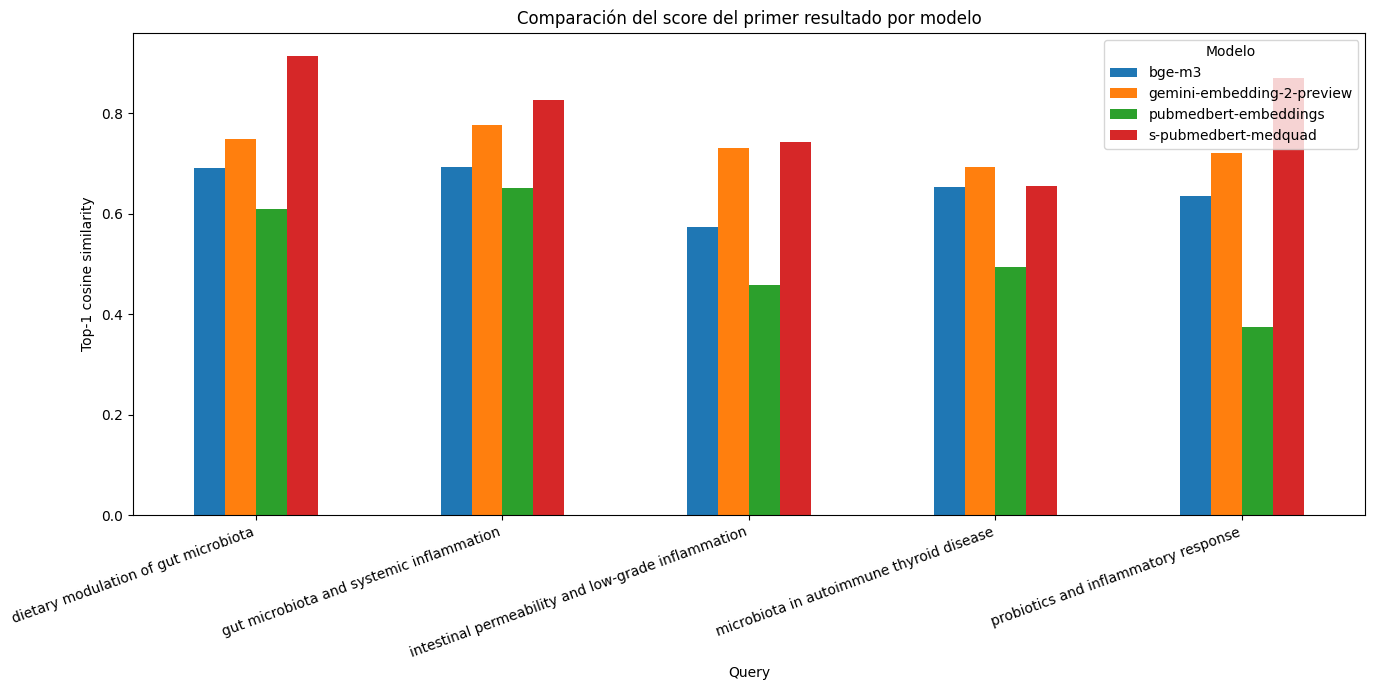

In [11]:
plot_top1_scores(df_summary)

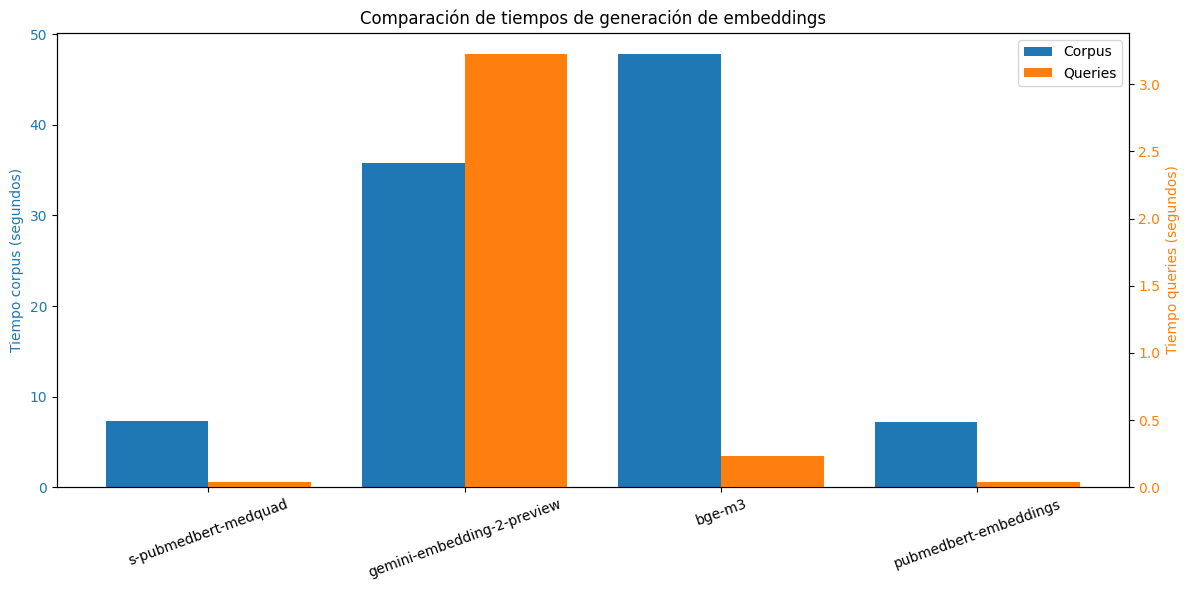

In [12]:
plot_encoding_times(df_models)


Helper para buscar y entender algún artículo mejor

In [13]:
article = next((a for a in articles if a.get("pmid") == "41829891"), None)
article


{'document_id': 'pubmed_41829891',
 'source': 'pubmed',
 'pmid': '41829891',
 'doi': '10.3390/nu18050720',
 'title': 'Migraine and the Gut-Brain Axis-The Role of Microbiome-Targeted Biotics.',
 'abstract': 'Background: Migraine is a highly prevalent and disabling primary headache disorder frequently accompanied by gastrointestinal symptoms and comorbid gastrointestinal diseases. Increasing evidence suggests that alterations in the gut microbiota and dysregulation of the microbiome-gut-brain axis may contribute to migraine pathophysiology through immune activation, oxidative stress, impaired intestinal barrier function, and neuroinflammatory signaling. Objectives: This narrative review aims to summarize current mechanistic and clinical evidence linking the gut-brain axis to migraine, with a particular focus on the potential roles of probiotics, prebiotics, and postbiotics as adjunctive strategies in migraine management. Methods: A narrative synthesis of experimental, translational, and 

## Conclusiones


### Selección del modelo de embeddings

Tras la comparación realizada entre distintos modelos de embeddings, se selecciona **bge-m3** como modelo principal para el sistema.

Aunque los modelos específicos del dominio biomédico, como **S-PubMedBert-MedQuAD**, han mostrado un mayor nivel de especialización en ciertos casos (por ejemplo, identificando mecanismos biológicos o entidades más concretas), su comportamiento resulta menos consistente, introduciendo mayor variabilidad en los resultados y, en ocasiones, recuperando documentos menos alineados con la intención de búsqueda.

La incorporación de **Gemini Embedding** permite añadir un punto de referencia adicional en términos de calidad semántica. Este modelo muestra un comportamiento sólido y coherente en la recuperación, con resultados generalmente bien alineados con las consultas. Sin embargo, presenta limitaciones relevantes para el contexto del proyecto: mayor latencia en la codificación de queries, dimensionalidad elevada (`3072`) y dependencia de un servicio externo, lo que implica mayor coste operativo y menor control sobre el despliegue.

Por el contrario, **bge-m3** presenta un comportamiento más estable y robusto a lo largo de las diferentes consultas, recuperando documentos relevantes de forma consistente, aunque con menor nivel de especialización biomédica.

Dado el carácter exploratorio del proyecto y su enfoque en una demo funcional, se prioriza la consistencia, reproducibilidad y capacidad de despliegue local frente a la especialización puntual o la máxima capacidad semántica. En este contexto, **bge-m3** se considera la opción que ofrece el mejor equilibrio entre robustez, calidad de recuperación y coste operativo.

---

### Medición de tiempos 

Se han medido los tiempos de generación de embeddings diferenciando entre el corpus de documentos y las consultas.

El tiempo de codificación del corpus (`corpus_encoding_time_sec`) corresponde al proceso de transformar todos los documentos en representaciones vectoriales. Este proceso se realiza de forma offline y normalmente solo una vez durante la fase de indexación.

Por otro lado, el tiempo de codificación de las queries (`query_encoding_time_sec`) corresponde a la generación de embeddings para las consultas de usuario. Este proceso se realiza en tiempo de ejecución y tiene un impacto directo en la latencia del sistema.

En los resultados obtenidos se observa que:

- Los modelos basados en **PubMedBERT** son los más rápidos en ambos escenarios.
- **bge-m3** presenta un mayor coste en CPU, especialmente en la generación del corpus.
- **Gemini Embedding** introduce una latencia significativamente superior en queries, debido a su naturaleza como servicio externo.

Por este motivo, aunque ambos tiempos son relevantes, el tiempo de codificación de las queries resulta especialmente crítico en sistemas de recuperación en tiempo real.

---

### Limitaciones

El sistema desarrollado presenta una serie de limitaciones derivadas tanto del enfoque adoptado como del alcance del proyecto:

- **Tamaño reducido del corpus:** El número de artículos indexados (10–50) es limitado en comparación con la magnitud real de PubMed, lo que condiciona la capacidad de recuperación y la diversidad de resultados.

- **Evaluación no sistemática:** La evaluación de los modelos de embeddings se ha realizado de forma cualitativa mediante inspección manual de resultados, sin el uso de métricas formales como precision@k, recall@k o datasets de benchmark.

- **Dependencia de la calidad del abstract:** El sistema se basa principalmente en el abstract del artículo, lo que puede limitar la representación completa del contenido científico.

- **Ausencia de re-ranking:** No se ha implementado una segunda fase de reordenación (reranking), que podría mejorar la precisión de los resultados recuperados.

- **No uso explícito de MeSH en embeddings:** Aunque se utilizan en la fase de búsqueda, los términos MeSH no se integran directamente en la representación vectorial, lo que podría limitar la captura de relaciones semánticas más estructuradas.

- **Dependencia del preprocesamiento:** La calidad del sistema está directamente condicionada por el filtrado en ESearch (`medline[sb]`, `hasabstract`) y la correcta extracción de campos como `ArticleTitle` y `AbstractText`.

---

### Líneas de mejora

A partir de los resultados obtenidos, se identifican varias líneas de mejora que podrían incrementar el rendimiento del sistema:

- **Aumento del corpus:** Escalar el número de artículos indexados para mejorar la cobertura temática y la calidad del retrieval.

- **Estrategia híbrida (BM25 + embeddings):** Combinar búsqueda léxica con búsqueda semántica para mejorar la recuperación inicial.

- **Re-ranking con modelos más potentes:** Incorporar un modelo de reranking (por ejemplo, cross-encoders biomédicos o LLMs) para refinar los resultados obtenidos.

- **Integración explícita de MeSH:** Incorporar términos MeSH como parte del embedding o como filtros estructurados.

- **Evaluación cuantitativa:** Definir métricas objetivas (precision@k, recall@k, MRR) y, si es posible, utilizar datasets de referencia biomédicos.

- **Actualización continua del corpus:** Implementar una estrategia de actualización periódica (por ejemplo, mediante update files de PubMed) para mantener el sistema alineado con nuevas publicaciones.

---

### Insight clave 

En sistemas de recuperación semántica:

- ❌ el mejor modelo no es el que obtiene la mayor puntuación de similitud  
- ✔️ es el que comete menos errores en el ranking de resultados  

La robustez y consistencia del modelo son factores más determinantes que la maximización de scores individuales.

---

### Posible opción avanzada

Una arquitectura más completa podría combinar diferentes modelos en distintas fases:

- **Retrieval:** `bge-m3`  
- **Re-ranking:** `S-PubMedBert-MedQuAD` o un modelo basado en LLM  
